In [67]:
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv("../rust/test_mse_log.csv")
df.head()

,composite_id,mse
0,1001,0.013136
1,1002,0.024824
2,1003,0.010694
3,1004,0.013908
4,1005,0.018855


In [68]:
df["unit_number"] = df["composite_id"] // 1000
df["time_in_cycles"] = df["composite_id"] % 1000

In [69]:
df.head()

,composite_id,mse,unit_number,time_in_cycles
0,1001,0.013136,1,1
1,1002,0.024824,1,2
2,1003,0.010694,1,3
3,1004,0.013908,1,4
4,1005,0.018855,1,5


In [70]:
# Calculate cycle_pct (how far into the engine's life is this cycle?)
# First, find the max cycle for each unit
max_cycles = df.groupby('unit_number')['time_in_cycles'].transform('max')
df['cycle_pct'] = df['time_in_cycles'] / max_cycles

# ==========================================
# SIMULATE SCENARIO A: Static Threshold
# ==========================================
# If MSE > 0.04 everywhere
df['flagged_static'] = df['mse'] > 0.04

# ==========================================
# SIMULATE SCENARIO B: Variable Threshold
# ==========================================

dynamic_threshold = np.where(df['time_in_cycles'] < 20, 0.05, 0.04)
df['flagged_variable'] = df['mse'] > dynamic_threshold

# ==========================================
# Analyze the Results
# ==========================================
print("--- TEST RESULTS ---")

early_life_df = df[df['cycle_pct'] <= 0.70]

# Count how many early false alarms happened under both scenarios
static_early_alarms = early_life_df['flagged_static'].sum()
variable_early_alarms = early_life_df['flagged_variable'].sum()

print(f"Early Alarms (Static 0.04):    {static_early_alarms}")
print(f"Early Alarms (Variable Fix):   {variable_early_alarms}")

# Calculate how many false alarms you successfully ignored!
saved_alarms = static_early_alarms - variable_early_alarms
if saved_alarms > 0:
    print(f"\nSUCCESS! successfully ignored {saved_alarms} break-in noise anomalies.")
else:
    print("\n something needs to be changed ")

--- TEST RESULTS ---
Early Alarms (Static 0.04):    13
Early Alarms (Variable Fix):   7

SUCCESS! successfully ignored 6 break-in noise anomalies.


In [71]:
df['flagged'] = df['flagged_variable']
late_count  = df[(df['cycle_pct'] > 0.70) & df['flagged']].shape[0]
early_count = df[(df['cycle_pct'] <= 0.70) & df['flagged']].shape[0]
print(f"late_cycle%: {late_count / (late_count + early_count):.1%}")

late_cycle%: 0.0%


count     7.000000
mean     32.571429
std      16.591736
min       3.000000
25%      27.000000
50%      38.000000
75%      39.000000
max      55.000000
Name: time_in_cycles, dtype: float64


<Axes: >

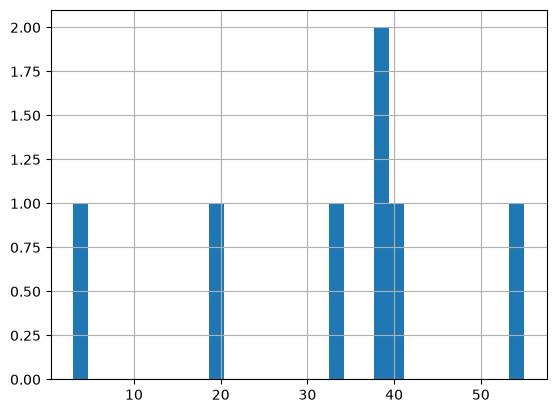

In [72]:
remaining_false = early_life_df[early_life_df['flagged_variable']]
print(remaining_false['time_in_cycles'].describe())
remaining_false['time_in_cycles'].hist(bins=30)


In [73]:
# test
test = df[df["unit_number"] == 3]
test

,composite_id,mse,unit_number,time_in_cycles,cycle_pct,flagged_static,flagged_variable,flagged
80,3001,0.008418,3,1,0.007937,False,False,False
81,3002,0.005481,3,2,0.015873,False,False,False
82,3003,0.009069,3,3,0.023810,False,False,False
83,3004,0.005389,3,4,0.031746,False,False,False
84,3005,0.004268,3,5,0.039683,False,False,False
...,...,...,...,...,...,...,...,...
201,3122,0.012370,3,122,0.968254,False,False,False
202,3123,0.011166,3,123,0.976190,False,False,False
203,3124,0.008790,3,124,0.984127,False,False,False
204,3125,0.016347,3,125,0.992063,False,False,False
